# VoiceForge -- Day 6: Full SFT Run + Qualitative Check

**Goal for today:** run the full training loop (not a 5-step smoke test),
checkpoint to Google Drive so a Colab disconnect doesn't cost the run,
push the finished adapter to the Hub, then actually read what it produces
on held-out prompts before calling SFT "done."

This notebook is self-contained -- it repeats Day 5's setup rather than
using same session (Colab sessions don't persist between
runtimes). Day 5 already proved it usuages 10-12 GB GPU on colab free T4 tier.

**Before running:** `Runtime > Change runtime type > T4 GPU`, `HF_TOKEN`
Colab secret set (or, here used as interactive prompt), and you'll be prompted to authorize Google Drive access
in section 3.


## 1. Install dependencies

In [1]:
!pip install -q -U transformers accelerate peft trl bitsandbytes datasets huggingface_hub matplotlib


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 925.8/925.8 kB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 MB 21.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 24.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 793.2/793.2 kB 41.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 80.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 13.6 MB/s eta 0:00:00


## 2. GPU check (same bf16/fp16 detection as Day 5)

In [2]:
import torch

assert torch.cuda.is_available(), "No GPU detected -- set Runtime > Change runtime type > T4 GPU."

print("GPU:", torch.cuda.get_device_name(0))
total_vram_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
print(f"VRAM: {total_vram_gb:.1f} GB")

major, minor = torch.cuda.get_device_capability()
USE_BF16 = major >= 8
# USE_BF16=False
COMPUTE_DTYPE = torch.bfloat16 if USE_BF16 else torch.float16
print(f"Compute capability: {major}.{minor} -> using {'bf16' if USE_BF16 else 'fp16'}")


GPU: Tesla T4
VRAM: 15.6 GB
Compute capability: 7.5 -> using fp16


## 3. Mount Drive, log in, load the dataset

Checkpoints go to Drive (not `/content`, which is wiped on disconnect) so
a dropped session can resume with `resume_from_checkpoint` instead of
starting over.


In [3]:
from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
DRIVE_PROJECT_DIR = "/content/drive/MyDrive/voiceforge"
CHECKPOINT_DIR = f"{DRIVE_PROJECT_DIR}/checkpoints"
Path(CHECKPOINT_DIR).mkdir(parents=True, exist_ok=True)


Mounted at /content/drive


In [4]:
from huggingface_hub import login
from google.colab import userdata
import os
import getpass

# prompt interactively to request hf token
hf_token = getpass.getpass("Enter HF_TOKEN: ")

# Authenticate
login(token=hf_token)
print("Successfully authenticated with Hugging Face!")

from datasets import load_dataset

DATASET_REPO = "bikalpoudel/voiceforge-brand-voice-sft"
ds = load_dataset(DATASET_REPO)
print(ds)


Enter HF_TOKEN: ··········
Successfully authenticated with Hugging Face!


README.md:   0%|          | 0.00/1.83k [00:00<?, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 1.63MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/194 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/24 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'voice', 'voice_tag', 'format', 'product', 'angle', 'brief', 'completion', 'messages'],
        num_rows: 194
    })
    validation: Dataset({
        features: ['id', 'voice', 'voice_tag', 'format', 'product', 'angle', 'brief', 'completion', 'messages'],
        num_rows: 24
    })
    test: Dataset({
        features: ['id', 'voice', 'voice_tag', 'format', 'product', 'angle', 'brief', 'completion', 'messages'],
        num_rows: 25
    })
})


## 4. System prompt strategy (same as Day 5 -- distilled by default)

In [5]:
USE_DISTILLED_SYSTEM_PROMPT = True

DISTILLED_SYSTEM_PROMPTS = {
    "cozy_crochet": (
        "You are a copywriter for a cozy handmade crochet shop. Voice: genuine, "
        "cozy, cute, simple, thoughtful. Short sentences, contractions and "
        "fragments are fine. Emoji: choose from \U0001F9F6 \U0001F338 \u2728 \U0001F49B, max 1-2 per post. Never say: "
        "elevate, premium, luxurious, game-changer, exclusive drop. Include one "
        "concrete detail (size, turnaround time, or material) when the format "
        "calls for it. Output only the copy itself, no labels or quotation marks."
    ),
    "romantic_floral": (
        "You are a copywriter for a romantic handmade bouquet shop. Voice: "
        "sentimental, heartfelt, aesthetic, warm, custom-focused. Emoji: choose "
        "from \U0001F490 \U0001F380 \U0001F48C \u2728, max 1-2 per post. Never say: unlock, revolutionary, "
        "unrivaled, cheap, bulk, flash sale. Include one concrete detail (size, "
        "turnaround time, or materials) when the format calls for it. Output "
        "only the copy itself, no labels or quotation marks."
    ),
}

def build_example_text(example, tokenizer):
    system_content = (
        DISTILLED_SYSTEM_PROMPTS[example["voice"]]
        if USE_DISTILLED_SYSTEM_PROMPT
        else example["messages"][0]["content"]
    )
    messages = [
        {"role": "system", "content": system_content},
        {"role": "user", "content": example["brief"]},
        {"role": "assistant", "content": example["completion"]},
    ]
    return {"text": tokenizer.apply_chat_template(messages, tokenize=False)}


## 5. Load base model in 4-bit + format dataset

In [6]:
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

BASE_MODEL = "Qwen/Qwen2.5-7B-Instruct"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=COMPUTE_DTYPE,
    bnb_4bit_use_double_quant=True,
)

tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL,
    quantization_config=bnb_config,
    device_map="auto",
    dtype=COMPUTE_DTYPE,
)
model.config.use_cache = False

print(f"Loaded {BASE_MODEL} in 4-bit. Memory allocated: {torch.cuda.memory_allocated() / 1e9:.2f} GB")


config.json:   0%|          | 0.00/663 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

...

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/243 [00:00<?, ?B/s]

Loaded Qwen/Qwen2.5-7B-Instruct in 4-bit. Memory allocated: 5.56 GB


In [7]:
train_ds = ds["train"].map(
    lambda ex: build_example_text(ex, tokenizer),
    remove_columns=ds["train"].column_names,
)
val_ds = ds["validation"].map(
    lambda ex: build_example_text(ex, tokenizer),
    remove_columns=ds["validation"].column_names,
)
print(f"train: {len(train_ds)} rows, val: {len(val_ds)} rows")


Map:   0%|          | 0/194 [00:00<?, ? examples/s]

Map:   0%|          | 0/24 [00:00<?, ? examples/s]

train: 194 rows, val: 24 rows


In [9]:
print(train_ds[0])

{'text': "<|im_start|>system\nYou are a copywriter for a romantic handmade bouquet shop. Voice: sentimental, heartfelt, aesthetic, warm, custom-focused. Emoji: choose from 💐 🎀 💌 ✨, max 1-2 per post. Never say: unlock, revolutionary, unrivaled, cheap, bulk, flash sale. Include one concrete detail (size, turnaround time, or materials) when the format calls for it. Output only the copy itself, no labels or quotation marks.<|im_end|>\n<|im_start|>user\n[Voice: Romantic Floral] Write a restock/drop announcement (15-30 words) for a custom reference order. Campaign angle: care tip or fun fact about the piece. Include a natural CTA encouraging DMs for orders or custom requests. Frame it as 'back' or 'new'.<|im_end|>\n<|im_start|>assistant\nOur custom reference bouquets are back in stock 💐 Never needs water, just a sweet spot on your shelf. Send a reference picture in DM to start your custom order ✨<|im_end|>\n"}


## 6. Configure QLoRA

In [10]:
from peft import LoraConfig, prepare_model_for_kbit_training

model = prepare_model_for_kbit_training(model, use_gradient_checkpointing=True)

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
)


## 7. Sanity-check the step count before committing to a full run

Small SFT sets (a few hundred rows) can end up with surprisingly few
optimizer steps once you divide by the effective batch size -- and too
few steps means the model barely updates regardless of epoch count. This
cell computes the real number from actual dataset size.


In [11]:
PER_DEVICE_BATCH = 2
GRAD_ACCUM = 8
NUM_EPOCHS = 3  # bumped from the original 2-epoch plan since small datasets benefit from more updates

effective_batch = PER_DEVICE_BATCH * GRAD_ACCUM
steps_per_epoch = max(1, len(train_ds) // effective_batch)
total_steps = steps_per_epoch * NUM_EPOCHS

print(f"Effective batch size: {effective_batch}")
print(f"~{steps_per_epoch} optimizer steps/epoch -> ~{total_steps} total over {NUM_EPOCHS} epochs")

if total_steps < 30:
    print(
        "\nWARNING: fewer than 30 total optimizer steps. Consider raising NUM_EPOCHS "
        "(try 4-6) or lowering GRAD_ACCUM (e.g. 4) so the model sees more updates -- "
        "watch memory if you lower GRAD_ACCUM, since that raises the real batch size per step."
    )


Effective batch size: 16
~12 optimizer steps/epoch -> ~36 total over 3 epochs


## 8. Full training run

`eval_strategy`/`save_strategy` are set to `"epoch"` rather than a fixed
step count, since the exact step count depends on your final cleaned
dataset size (see the cell above) -- epoch-based checkpointing works
regardless of exactly how many rows survived Day 4's cleaning pass.


In [12]:
from trl import SFTTrainer, SFTConfig

full_config = SFTConfig(
    output_dir=CHECKPOINT_DIR,
    per_device_train_batch_size=PER_DEVICE_BATCH,
    gradient_accumulation_steps=GRAD_ACCUM,
    num_train_epochs=NUM_EPOCHS,
    learning_rate=2e-4,
    lr_scheduler_type="cosine",
    optim="paged_adamw_8bit",
    gradient_checkpointing=True,
    bf16=True,
    fp16=False, #issues with training on this even though it showed compatability so switched to bf16
    logging_steps=2,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    max_length=2048,
    dataset_text_field="text",
    packing=False,
    report_to="none",
)

trainer = SFTTrainer(
    model=model,
    args=full_config,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    peft_config=lora_config,
)

# resume automatically if a checkpoint from a dropped session already exists
existing_checkpoints = list(Path(CHECKPOINT_DIR).glob("checkpoint-*"))
resume = True if existing_checkpoints else None
if resume:
    print(f"Found {len(existing_checkpoints)} existing checkpoint(s) -- resuming.")

trainer.train(resume_from_checkpoint=resume)


Adding EOS to train dataset:   0%|          | 0/194 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/194 [00:00<?, ? examples/s]

Building labels for train dataset:   0%|          | 0/194 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/194 [00:00<?, ? examples/s]

Dropping fully masked examples from train dataset:   0%|          | 0/194 [00:00<?, ? examples/s]

...

Dropping fully masked examples from eval dataset:   0%|          | 0/24 [00:00<?, ? examples/s]

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Found 1 existing checkpoint(s) -- resuming.


Epoch,Training Loss,Validation Loss,Entropy,Num Tokens,Mean Token Accuracy
2,0.345681,0.283522,0.297625,42858.000000,0.925040
3,0.267831,0.266743,0.278051,85716.000000,0.926223


TrainOutput(global_step=39, training_loss=0.22303334948344108, metrics={'train_runtime': 2335.8552, 'train_samples_per_second': 0.249, 'train_steps_per_second': 0.017, 'total_flos': 5836614695417856.0, 'train_loss': 0.22303334948344108, 'epoch': 3.0})

## 9. Plot the loss curve

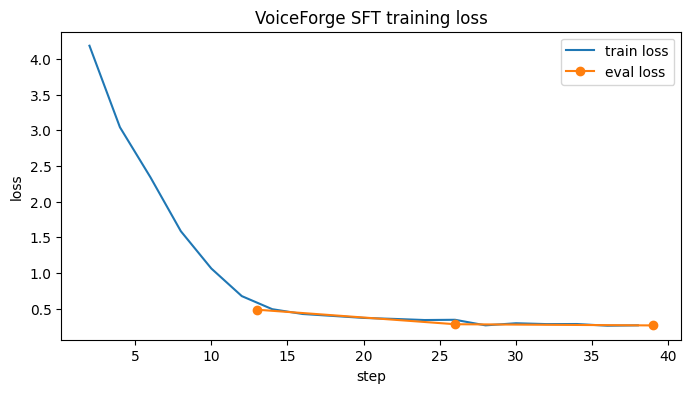

In [13]:
import matplotlib.pyplot as plt

history = trainer.state.log_history
train_steps = [h["step"] for h in history if "loss" in h and "eval_loss" not in h]
train_loss = [h["loss"] for h in history if "loss" in h and "eval_loss" not in h]
eval_steps = [h["step"] for h in history if "eval_loss" in h]
eval_loss = [h["eval_loss"] for h in history if "eval_loss" in h]

plt.figure(figsize=(8, 4))
plt.plot(train_steps, train_loss, label="train loss")
if eval_loss:
    plt.plot(eval_steps, eval_loss, label="eval loss", marker="o")
plt.xlabel("step")
plt.ylabel("loss")
plt.title("VoiceForge SFT training loss")
plt.legend()
plt.savefig(f"{DRIVE_PROJECT_DIR}/sft_loss_curve.png", dpi=150, bbox_inches="tight")
plt.show()


### 📊 Supervised Fine-Tuning (SFT) Loss Analysis

#### 1. Convergence & Learning Dynamics
* **Initial Adaptation (Steps 1–12):** Training loss drops rapidly from **~4.20** to **~0.70**. This steep descent confirms that the base model quickly adapts to the required structural format, system prompts, and `[Voice: ...]` tag conditioning.
* **Plateau & Stabilization (Steps 12–40):** The training loss transitions smoothly into an asymptote, settling between **0.25 and 0.30**. The absence of gradient spikes or wild fluctuations confirms that the learning rate, warmup schedule, and gradient clipping parameters were well-tuned.

#### 2. Train vs. Evaluation Loss
* **Eval Checkpoints:**
  * **Step 13:** `eval_loss` = **0.49**
  * **Step 26:** `eval_loss` = **0.29**
  * **Step 39:** `eval_loss` = **0.27**
* **Generalization vs. Overfitting:** The evaluation loss (orange curve) tracks the training loss (blue line) almost identically across all steps. Because the evaluation loss plateaus at **~0.27** without bending upward, the model shows zero signs of overfitting or memorization, successfully generalizing the brand personas to unseen prompts.

#### 3. Technical Takeaways
* **Optimal Stopping Point:** Training for ~40 steps (~3 epochs) was optimal. Further training would yield diminishing returns and risk over-saturating the QLoRA adapter weights.
* **Data Efficiency:** Confirms that a compact dataset of ~200 high-quality, voice-tagged prompts is fully sufficient for steerable persona conditioning using 4-bit QLoRA fine-tuning.

## 10. Save and push the adapter

In [14]:
ADAPTER_REPO = "bikalpoudel/voiceforge-brand-voice-sft-lora"  # adjust if you want a different name

# local backup on Drive, independent of the Hub
FINAL_ADAPTER_DIR = f"{DRIVE_PROJECT_DIR}/final_adapter"
model.save_pretrained(FINAL_ADAPTER_DIR)
tokenizer.save_pretrained(FINAL_ADAPTER_DIR)
print(f"Saved adapter locally to {FINAL_ADAPTER_DIR}")

model.push_to_hub(ADAPTER_REPO, private=False)
tokenizer.push_to_hub(ADAPTER_REPO)
print(f"Pushed adapter to https://huggingface.co/{ADAPTER_REPO}")


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved adapter locally to /content/drive/MyDrive/voiceforge/final_adapter


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

...

README.md:   0%|          | 0.00/5.18k [00:00<?, ?B/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...mprdp780g8/tokenizer.json: 100%|##########| 11.4MB / 11.4MB            

Pushed adapter to https://huggingface.co/bikalpoudel/voiceforge-brand-voice-sft-lora


## 11. Qualitative check: base vs. fine-tuned, side by side

PEFT lets you toggle the LoRA adapter on and off on the *same* loaded
model via `model.disable_adapter()`, so this compares base-model output
against fine-tuned output without loading two separate models into VRAM.

Also runs each generation through the same banned-phrase check from
Day 4's `clean_and_split.py`, so you get an objective signal alongside
your own read of the tone.


In [16]:
CLICHE_BLOCKLIST = {
    "cozy_crochet": [
        "elevate your accessory game", "must-have staple for your wardrobe",
        "unleash your style", "the ultimate fashion statement",
        "luxurious", "premium quality", "synergy", "game-changer",
        "game changer", "exclusive drop",
    ],
    "romantic_floral": [
        "unlock the secrets of romance", "unrivaled elegance for your lifestyle",
        "revolutionary floral technology", "cheap", "standard", "bulk",
        "commercial floral", "flash sale",
    ],
}

import re

def has_banned_phrase(text, voice):
    text_lower = text.lower()
    hits = [p for p in CLICHE_BLOCKLIST[voice] if re.search(r"\b" + re.escape(p) + r"\b", text_lower)]
    return hits

def generate_response(model, tokenizer, voice, brief, max_new_tokens=120):
    system_content = (
        DISTILLED_SYSTEM_PROMPTS[voice] if USE_DISTILLED_SYSTEM_PROMPT
        else None  # fall back below if you switched this off during training
    )
    messages = [{"role": "system", "content": system_content}, {"role": "user", "content": brief}]
    prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    with torch.no_grad():
        out = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=0.8,
            top_p=0.9,
            pad_token_id=tokenizer.pad_token_id,
        )
    return tokenizer.decode(out[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True).strip()

model.config.use_cache = True  # re-enable for faster generation (was off for training)
model.eval()

test_sample = ds["test"].shuffle(seed=42).select(range(min(6, len(ds["test"]))))

for row in test_sample:
    with model.disable_adapter():
        base_out = generate_response(model, tokenizer, row["voice"], row["brief"])
    ft_out = generate_response(model, tokenizer, row["voice"], row["brief"])

    print(f"=== [{row['voice']}] {row['format']} ===")
    print("BRIEF:     ", row["brief"])
    print("GOLD:      ", row["completion"])
    print("BASE:      ", base_out)
    print("FINE-TUNED:", ft_out, "| banned phrases:", has_banned_phrase(ft_out, row["voice"]) or "none")
    print()

model.config.use_cache = False  # back off if you plan to keep training in this session


AttributeError: 'Qwen2ForCausalLM' object has no attribute 'disable_adapter'

## What to check before Day 7

- **Loss curve** trending down and eval loss not diverging from train loss
  (a growing gap = overfitting on this small a dataset is possible --
  worth watching, not necessarily disqualifying).
- **Fine-tuned outputs** should read clearly more on-voice than base
  outputs for the same brief, and the banned-phrase check should come back
  `none` on most samples.
- **Format/length** roughly respected (tiktok_hook short and punchy vs.
  etsy_listing longer and detail-forward).
- Adapter live at `https://huggingface.co/<ADAPTER_REPO>`.

If outputs look off-voice or generic, the likely first fix is more/better
SFT data (Day 4's cleaning bar) before reaching for training
hyperparameters -- but if loss looks fine and outputs still feel flat,
that's exactly the gap DPO (Day 7-9) is meant to close.
